# Front isopycnal curtains — pick a tile, pick a front, cut the curtains

This notebook walks the whole `fronts_viz_curtain` workflow by hand, in order, with
**three places where you choose something**.  Each one is a cell that starts with a
`# >>> USER INPUT` banner — set the variables there, run the cell, look at the figure
it prints, then move on.

| Step | Cell | You choose |
|---|---|---|
| 0 | Global tile map | — (just look at it) |
| a | Tile + field | **1 of 3:** `TILE` (or `LAT`/`LON`) and `FIELD` |
| b | Front map of the tile | — (just look at it) |
| c | Front pick + along-front tickmarks | **2 of 3:** `FRONT_LABEL` |
| d | All five curtain figures | **3 of 3:** `CROSS_SECTION_AT` |

Every choice is made by reading a label off the figure the previous cell drew: a tile
number off the global map, a front number off the tile map, a tickmark name off the
front inset.

Everything is read from one snapshot: **2012-11-09 12:00:00**
(`s3://dbof/LLC4320_RAW/DEPTH/20121109T12.zarr` for the tiles, the V5 SURF front
products for the labels).  Nothing here writes to the preprocessing repo.

Docs: [docs/viz/fronts_curtain.md](../../../docs/viz/fronts_curtain.md).

*Generated by LH and Claude.*

## Setup — paths and the one snapshot everything comes from

`FRONTS_DIR` is the V5 SURF product directory; the four front files are found in it by
name pattern, exactly as `build_v4` writes them (`labeled_fronts_global_*.npy`,
`front_index_*.parquet`, `front_properties_*.parquet`, `*_bfronts.npy`).
`TILE_DIR` is where the two NetCDF tiles and the output PNGs land.  The tile loaders
live in `dev/mld/`, next to the package rather than inside it, so that goes on
`sys.path` here.

In [1]:
# Several repo modules force the Agg backend when they are imported, so this
# line reappears at the top of every cell that draws a figure.
%matplotlib inline

import glob
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import fronts

# dev/mld holds the tile loaders that fronts_viz_curtain itself uses; it sits
# beside the package, not inside it, so it goes on sys.path by hand.
DEV_MLD = Path(fronts.__file__).resolve().parents[1] / 'dev' / 'mld'
if str(DEV_MLD) not in sys.path:
    sys.path.insert(0, str(DEV_MLD))

from density_utils import (load_density_tile, load_tile, load_labels_tile,
                           build_tile_lookup, tile_scalar)

# ---- the snapshot -------------------------------------------------------
TIMESTAMP = '2012-11-09 12:00:00'       # for the tile generator (dbof DATE_FMT)

# ---- where the fronts live (V5, SURF pipeline) --------------------------
FRONTS_DIR = Path('/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V5/SURF/20121109_120000')

# ---- where tiles and figures go ----------------------------------------
TILE_DIR   = FRONTS_DIR / 'tiles'
TILE_DIR.mkdir(parents=True, exist_ok=True)


def find_one(pattern, required=True):
    """The single file in FRONTS_DIR matching *pattern* (None if optional + absent)."""
    hits = sorted(glob.glob(str(FRONTS_DIR / pattern)))
    if len(hits) == 1:
        return Path(hits[0])
    if required:
        raise FileNotFoundError(f"expected 1 match for {pattern} in {FRONTS_DIR}, got {hits}")
    return None


# The one file this notebook actually reads (build_v4 step 3, 'label_map').
LABELS_FILE = find_one('labeled_fronts_global_*.npy')

# The rest of the V5 products, listed so you can see the run is complete.
COMPANIONS = {
    'binary fronts (step 2)': find_one('*_bfronts.npy', required=False),
    'front index   (step 3)': find_one('front_index_*.parquet', required=False),
    'geometry      (step 3)': find_one('global_front_geometry_*.parquet', required=False),
    'properties    (step 4)': find_one('front_properties_*.parquet', required=False),
}

print(f"labels                 : {LABELS_FILE.name}")
for name, path in COMPANIONS.items():
    print(f"{name} : {path.name if path else '-- not found --'}")
print(f"tiles + figures -> {TILE_DIR}")

labels                 : labeled_fronts_global_20121109T12_00_00_V5_bfronts.npy
binary fronts (step 2) : -- not found --
front index   (step 3) : front_index_20121109T12_00_00_V5_bfronts.parquet
geometry      (step 3) : global_front_geometry_20121109T12_00_00_V5_bfronts.parquet
properties    (step 4) : -- not found --
tiles + figures -> /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V5/SURF/20121109_120000/tiles


## Step 0 — the global tile map

One figure: coastlines, lat/lon axes, and all **432 LLC4320 tiles numbered by
`tile_idx`**.  A tile is a 720 × 720 block of the stitched rectangular grid
(18 rows × 24 columns), `tile_idx = tile_j * 24 + tile_i`.  The stitched grid drops the
LLC Arctic cap, so the map stops near 72°N.

Read a tile number off this map (or just note a lat/lon you care about) and use it in
the next cell.  Same tile numbering as
`llc4320-native-grid-preprocessing/notebooks/notebooks_viz/tile_selection_regions_gradb2.ipynb`
— that notebook adds the `gradb2` field underneath; this one deliberately does not.

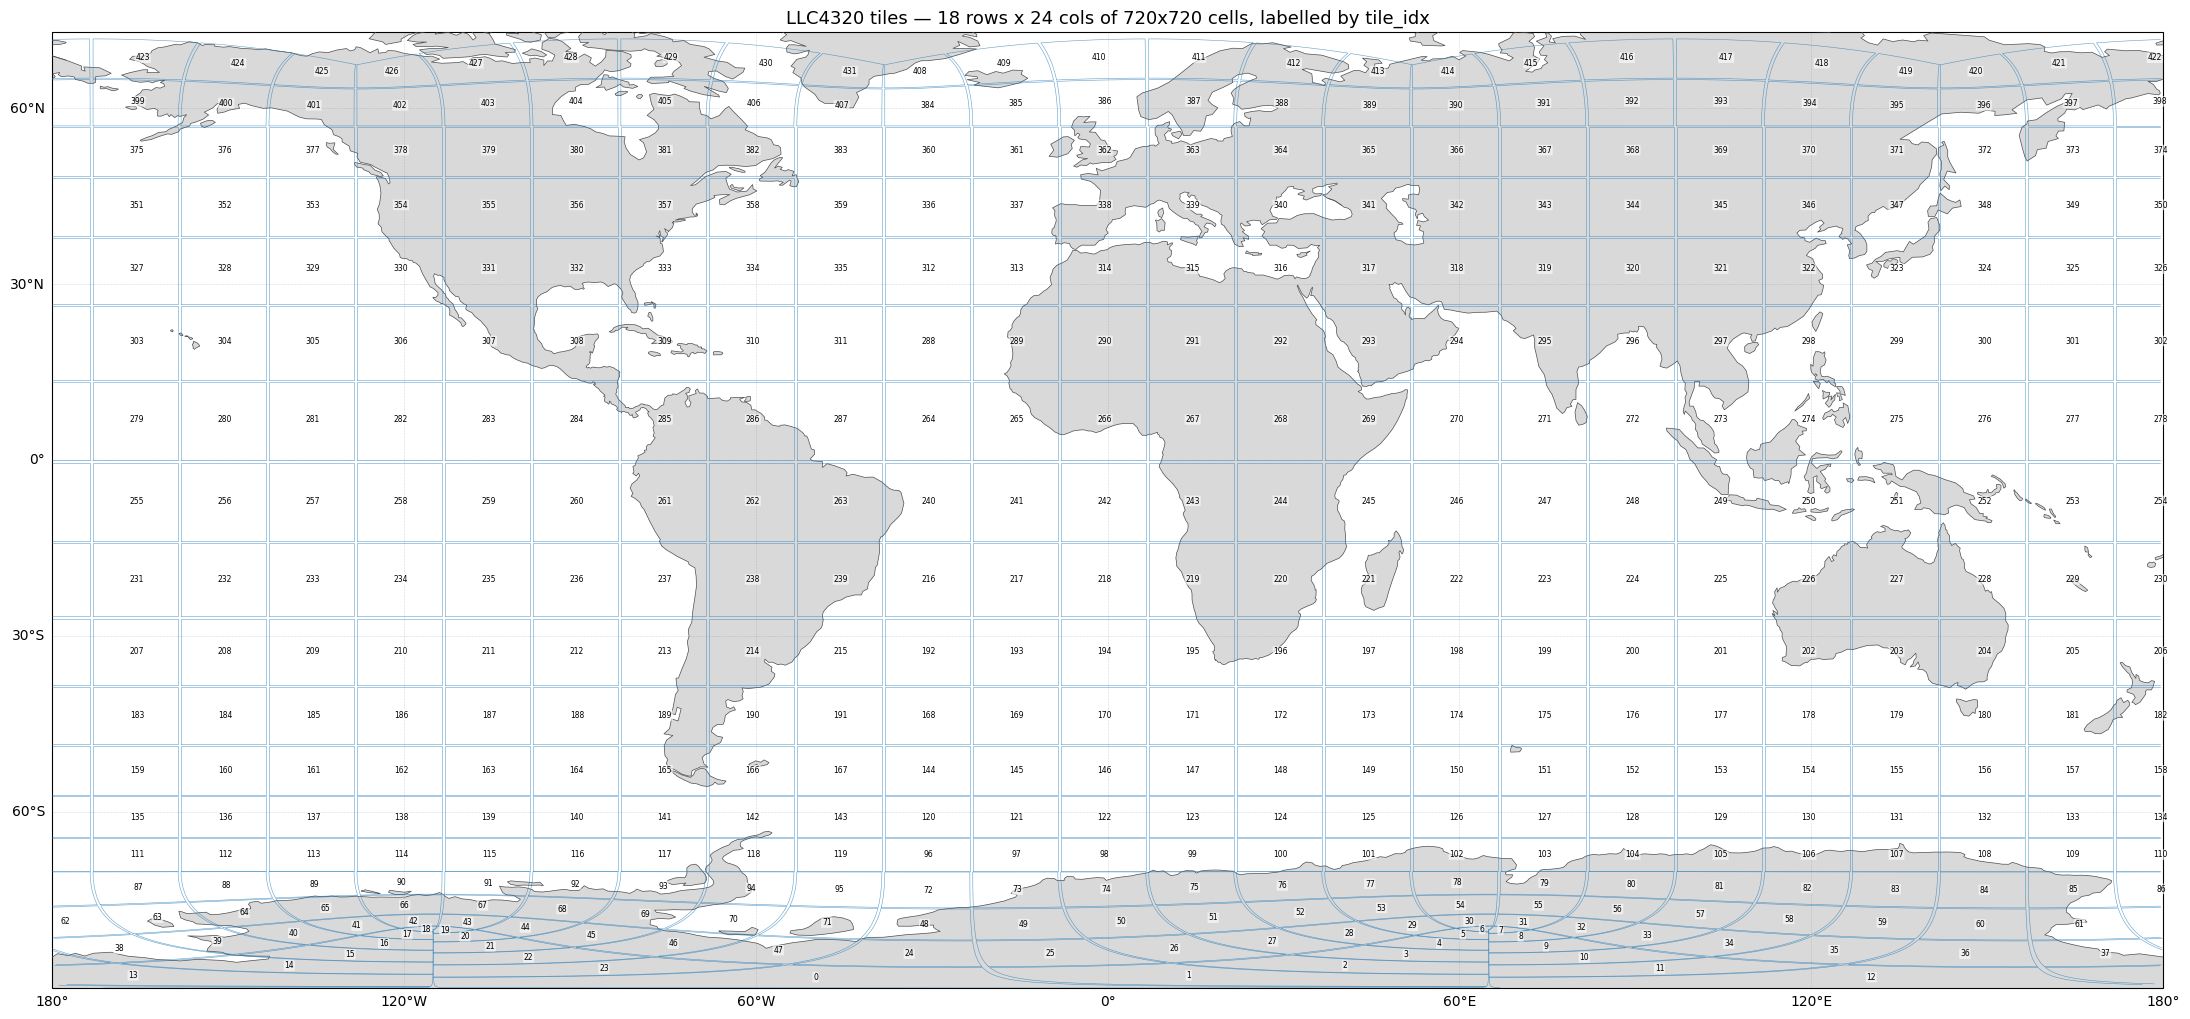

In [2]:
%matplotlib inline

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from dbof.tiles.tile_mapping import TILE_SIZE, N_TILE_I, N_TILE_J, N_TILES
from fronts.properties.viz_loaders import load_llc_coords

STRIDE = 12                              # 720 % 12 == 0, so tiles stay exact
TS     = TILE_SIZE // STRIDE             # 60 strided cells per tile side

lat, lon = load_llc_coords(downsample_factor=STRIDE)   # (1080, 1440) each


def tile_slices(t):
    """Strided-array (j_slice, i_slice) of tile *t*."""
    tj, ti = divmod(int(t), N_TILE_I)
    return slice(tj * TS, (tj + 1) * TS), slice(ti * TS, (ti + 1) * TS)


def tile_centre_lonlat(t):
    """(lon, lat) of the centre cell of tile *t*."""
    js, iss = tile_slices(t)
    jc, ic = (js.start + js.stop) // 2, (iss.start + iss.stop) // 2
    return float(lon[jc, ic]), float(lat[jc, ic])


def tile_outline(t, step=2):
    """Closed lon/lat outline of tile *t*, split at the +/-180 seam."""
    js, iss = tile_slices(t)
    jj = np.arange(js.start, js.stop, step)
    ii = np.arange(iss.start, iss.stop, step)
    ring_j = np.concatenate([np.full(ii.size, jj[0]), jj,
                             np.full(ii.size, jj[-1]), jj[::-1], [jj[0]]])
    ring_i = np.concatenate([ii, np.full(jj.size, ii[-1]),
                             ii[::-1], np.full(jj.size, ii[0]), [ii[0]]])
    x = (lon[ring_j, ring_i].astype(float) + 180.0) % 360.0 - 180.0
    y = lat[ring_j, ring_i].astype(float)
    cut = np.where(np.abs(np.diff(x)) > 180.0)[0] + 1     # don't smear the seam
    return [(a, b) for a, b in zip(np.split(x, cut), np.split(y, cut)) if a.size > 1]


PC = ccrs.PlateCarree()
fig = plt.figure(figsize=(22, 12))
ax = plt.subplot(1, 1, 1, projection=PC)
ax.set_extent([-180, 180, -90, float(np.ceil(np.nanmax(lat) + 1))], crs=PC)
ax.add_feature(cfeature.LAND, facecolor='0.85', zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='0.3', zorder=3)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='0.5', alpha=0.6,
                  linestyle=':', zorder=2)
gl.top_labels = gl.right_labels = False

for t in range(N_TILES):
    for xs, ys in tile_outline(t):
        ax.plot(xs, ys, transform=PC, color='tab:blue', lw=0.4, alpha=0.7, zorder=4)
    lonc, latc = tile_centre_lonlat(t)
    ax.text(lonc, latc, str(t), transform=PC, ha='center', va='center',
            fontsize=5.5, color='k', zorder=5,
            bbox=dict(boxstyle='round,pad=0.10', fc='w', ec='none', alpha=0.6))

ax.set_title(f"LLC4320 tiles — {N_TILE_J} rows x {N_TILE_I} cols of "
             f"{TILE_SIZE}x{TILE_SIZE} cells, labelled by tile_idx", fontsize=13)
plt.tight_layout()
plt.show()

## Step (a) — USER INPUT: which tile, and which field?

Two decisions:

1. **Where.**  Either set `TILE` to a number off the map above and leave `LAT`/`LON`
   as `None`, or set `LAT`/`LON` (degrees) and leave `TILE` as `None`.
2. **Which field** colours the curtains.  Density is always generated (it drives the
   isopycnals); `FIELD` is the second one.

The cell then generates both tiles from
`s3://dbof/LLC4320_RAW/DEPTH/20121109T12.zarr`.  Generating a tile takes a few
minutes; re-running the cell reuses whatever is already on disk (set `CLOBBER = True`
to force a rebuild).

Generation runs as a **subprocess** (`python -m dbof.cli.generate_tile`), the same way
`dev/mld/gen_tiles.sh` has always called it, rather than importing the generator here.
Two reasons: the tile writer uses `h5netcdf`, and HDF5 gets unhappy when a process has
already opened NetCDF files through a different HDF5 build (the
`RuntimeError: Unspecified error in H5DSis_scale` failure mode) — a fresh process
sidesteps it entirely; and importing the generator would drag the `Agg` matplotlib
backend into this kernel.

In [9]:
# ===========================================================================
# >>> USER INPUT (1 of 3) — pick the tile and the field <<<
# ===========================================================================

# --- WHERE: set EITHER a tile number OR a lat/lon.  Leave the other None. --
TILE = 330            # tile_idx from the map above, e.g. 330
LAT  = None           # e.g. 36.4       (only used when TILE is None)
LON  = None           # e.g. -124.2     (only used when TILE is None)

# --- WHICH FIELD colours the curtains -------------------------------------
# Pick ONE name from this list (density is always generated alongside it).
# These are the full-depth (3-D) fields — curtains need a water column, so the
# inherently 2-D channels (mixed_layer_depth, ml_heat_content, Eta, gradeta2,
# ug, vg, coriolis_f) are deliberately not offered here.
#
#   stratification : N2
#   shear / mixing : vertical_shear  Ri  Fr  Ro  Bu  R_ib
#   potential vort : ertel_pv  ertel_pv_vertical  ertel_pv_tilt
#   buoyancy flux  : uB  vB  wB
#   energetics     : KE
#   fronts         : gradb2  gradtheta2  gradsalt2  gradrho2  turner_angle
#   kinematics     : relative_vorticity  strain_n  strain_s  strain_mag
#                    divergence  rossby_number  okubo_weiss
#   frontogenesis  : frontogenesis_tendency  frontogenesis_geo
#                    frontogenesis_ageo  Wstar
#   native fields  : Theta  Salt  U  V  W  (aliases: temperature, salinity)
#
# Note: Theta and Salt are styled with cmocean colormap names, which the repo
# does not register with matplotlib — the cells below fall back to viridis, but
# fronts_viz_curtain itself will want `--cmap` set for those two.
#
FIELD = 'Ri'

CLOBBER = False       # True = regenerate the tiles even if they already exist

# ===========================================================================
# End of user input — the rest of the cell just runs the tile generator.
# ===========================================================================
import subprocess
from datetime import datetime

from dbof.tiles.field_registry import resolve_property

if (TILE is None) == (LAT is None or LON is None):
    raise ValueError("Set EITHER TILE or (LAT and LON) — exactly one of the two.")

# Resolve the request to a tile index, then to that tile's centre pixel.  Going
# via the tile index means the output filenames are known up front, either way.
if TILE is not None:
    TILE_IDX = int(TILE)
else:
    dlon = np.abs(((lon - LON + 180.0) % 360.0) - 180.0)
    jS, iS = np.unravel_index(np.nanargmin(np.abs(lat - LAT) + dlon), lat.shape)
    TILE_IDX = (jS // TS) * N_TILE_I + (iS // TS)
    print(f"lon={LON}, lat={LAT} -> tile {TILE_IDX}")

tj, ti = divmod(TILE_IDX, N_TILE_I)
I_RECT = ti * TILE_SIZE + TILE_SIZE // 2
J_RECT = tj * TILE_SIZE + TILE_SIZE // 2
STAMP  = datetime.strptime(TIMESTAMP, '%Y-%m-%d %H:%M:%S').strftime('%Y%m%dT%H')
print(f"tile {TILE_IDX} -> rect centre pixel (i={I_RECT}, j={J_RECT})")


def usable(path):
    """True only if *path* is a COMPLETE tile.

    A write that died part-way (e.g. the h5netcdf/HDF5 failure this cell exists
    to avoid) leaves a file that exists but has no provenance attributes, and
    'it exists so reuse it' would then hand that stub to the next cell.  So ask
    the real loader instead of trusting the directory entry.
    """
    if not path.exists():
        return False
    try:
        load_tile(path).close()
        return True
    except Exception as err:
        print(f"  ! {path.name} is not a usable tile ({type(err).__name__}) "
              "— regenerating it")
        return False


def generate_tile(prop):
    """Generate one property tile in a subprocess; return the NetCDF path."""
    out = TILE_DIR / f"{resolve_property(prop).filename_prefix}_tile{TILE_IDX:03d}_{STAMP}.nc"
    if not CLOBBER and usable(out):
        print(f"{prop:>10s}: already on disk, reusing {out.name}")
        return out
    # --clobber whenever anything is in the way, else the CLI just skips it.
    cmd = [sys.executable, '-m', 'dbof.cli.generate_tile',
           '--i', str(I_RECT), '--j', str(J_RECT),
           '--timestamp', TIMESTAMP, '--property', prop,
           '--output', str(TILE_DIR)] + (['--clobber'] if out.exists() else [])
    print(f"\n$ {' '.join(cmd)}", flush=True)

    # Pipe the child's output into THIS cell.  Without the pipe it goes to the
    # terminal running the kernel, where you cannot see it, and a failure shows
    # up here as a bare non-zero exit status with no explanation.
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end='', flush=True)
    if proc.wait() != 0:
        raise RuntimeError(f"generate-tile exited {proc.returncode} for "
                           f"'{prop}' — the reason is in the log above")

    if not usable(out):
        raise RuntimeError(f"the generator finished but {out} is still not a "
                           "readable tile — check its log output above")
    return out


DENSITY_TILE = generate_tile('density')
FIELD_TILE   = generate_tile(FIELD)

print(f"\ndensity tile : {DENSITY_TILE}")
print(f"{FIELD} tile : {FIELD_TILE}")

tile 330 -> rect centre pixel (i=13320, j=9720)
   density: already on disk, reusing density_tile330_20121109T12.nc
        Ri: already on disk, reusing ri_tile330_20121109T12.nc

density tile : /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V5/SURF/20121109_120000/tiles/density_tile330_20121109T12.nc
Ri tile : /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V5/SURF/20121109_120000/tiles/ri_tile330_20121109T12.nc


## Step (b) — the tile's surface, with every front numbered

The tile's near-surface `FIELD` slice, with the V5 front pixels drawn on top and each
front **labelled by its label number** — these are the numbers you pick from in the
next cell.  Fronts shorter than `MIN_FRONT_PIXELS` are drawn but not numbered, so the
map stays readable.

Two frames are in play and this cell is where they get reconciled: the tiles are
*face-local*, the labels are on the *rect* grid.  `build_tile_lookup` + `remap_to_rect`
put the tile onto the rect frame, which is the frame `--i/--j` speaks.

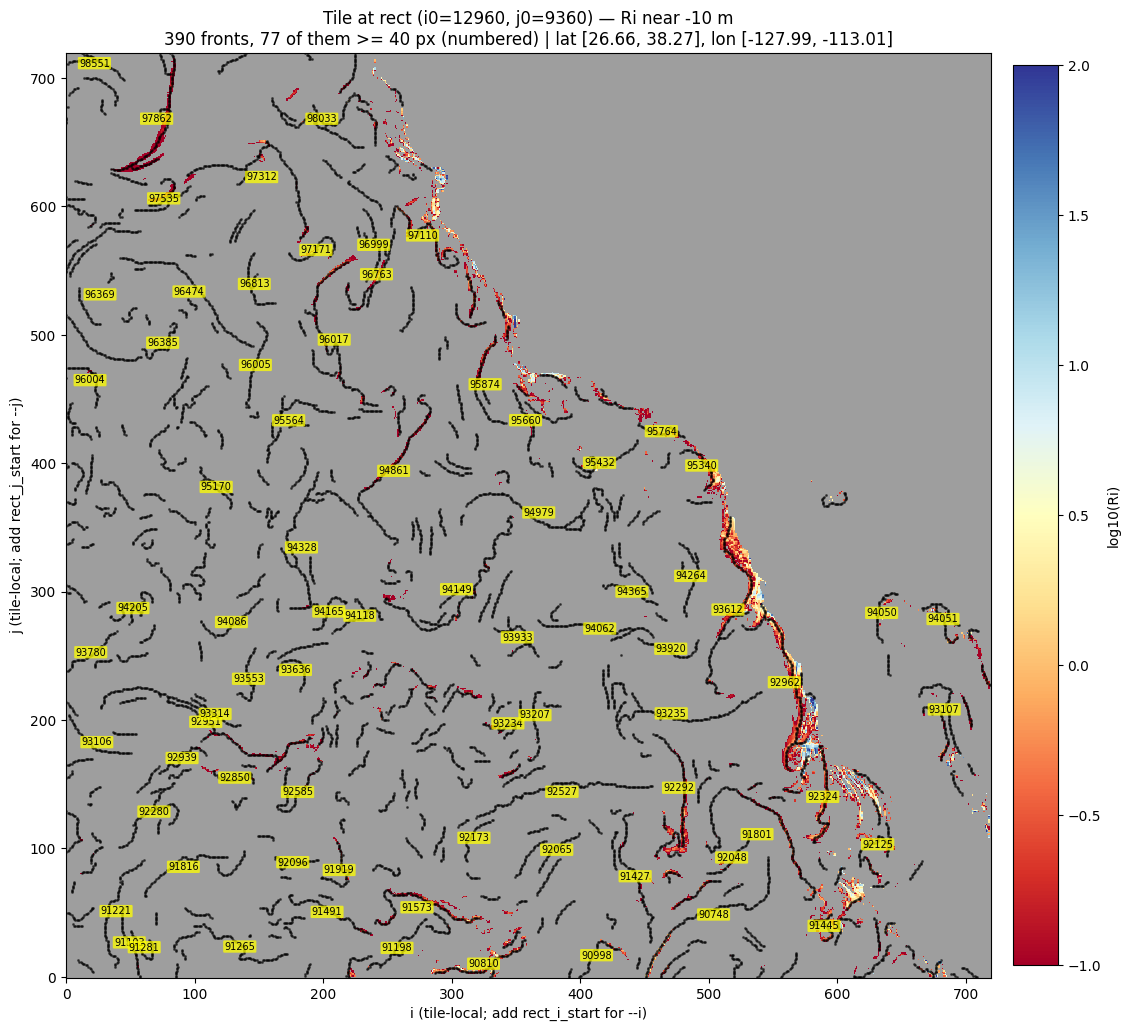

longest fronts in this tile (label: pixels)
  92951:245   94149:201   91801:179   93612:173   97312:168   92962:167   94328:167   96017:165   98033:164   93235:163   97862:161   92527:148   90748:144   94861:138   96369:132   94979:131   96474:118   91427:113   91573:113   92280:110


In [10]:
%matplotlib inline

from fronts.scripts.fronts_viz_3d import remap_to_rect
from fronts.viz.field_styles import apply_transform, default_clim, get_style, NAN_COLOR

MIN_FRONT_PIXELS = 40        # only number fronts at least this long

# ---- load the two tiles + the labels window ------------------------------
ds_den   = load_density_tile(DENSITY_TILE)
ds_field = load_tile(FIELD_TILE)
fname    = ds_field.attrs['tile_var_name']

rect_i0 = int(tile_scalar(ds_den, 'rect_i_start'))
rect_j0 = int(tile_scalar(ds_den, 'rect_j_start'))
face    = int(tile_scalar(ds_den, 'face_index'))

j_look, i_look = build_tile_lookup(rect_i0, rect_j0, face)
labels_tile = load_labels_tile(LABELS_FILE,
                              slice(rect_j0, rect_j0 + j_look.shape[0]),
                              slice(rect_i0, rect_i0 + j_look.shape[1]))

Z       = ds_den['Z'].values.astype(float)
XC_rect = remap_to_rect(ds_den['XC'].values, j_look, i_look)
YC_rect = remap_to_rect(ds_den['YC'].values, j_look, i_look)
k_surf  = int(np.abs(np.abs(Z) - 10.0).argmin())        # ~10 m
surf    = remap_to_rect(ds_field[fname].values[k_surf], j_look, i_look)

style = get_style(fname)
disp  = apply_transform(surf, style)
clim  = default_clim(disp, style)

try:                                  # some styles name cmocean colormaps
    cmap = plt.get_cmap(style.cmap).copy()
except ValueError:
    print(f"! colormap '{style.cmap}' is not registered — using viridis")
    cmap = plt.get_cmap('viridis').copy()
cmap.set_bad(NAN_COLOR)

# ---- fronts in this tile: pixel count and centroid per label -------------
jj_all, ii_all = np.where(labels_tile > 0)
lab_flat = labels_tile[jj_all, ii_all]
lab_ids, inv = np.unique(lab_flat, return_inverse=True)
npix = np.bincount(inv)
j_bar = np.bincount(inv, weights=jj_all) / npix
i_bar = np.bincount(inv, weights=ii_all) / npix
FRONTS = {int(lb): dict(npix=int(n), j=float(jb), i=float(ib))
          for lb, n, jb, ib in zip(lab_ids, npix, j_bar, i_bar)}
big = sorted((lb for lb, d in FRONTS.items() if d['npix'] >= MIN_FRONT_PIXELS),
             key=lambda lb: -FRONTS[lb]['npix'])

# ---- the map -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(np.ma.masked_invalid(disp), origin='lower', cmap=cmap,
               vmin=clim[0], vmax=clim[1], interpolation='nearest')
fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02).set_label(style.title or fname)

ax.scatter(ii_all, jj_all, s=1.2, c='k', alpha=0.5)
for lb in big:
    ax.text(FRONTS[lb]['i'], FRONTS[lb]['j'], str(lb), fontsize=7, color='k',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.12', fc='yellow', ec='none', alpha=0.75))

ax.set_xlabel('i (tile-local; add rect_i_start for --i)')
ax.set_ylabel('j (tile-local; add rect_j_start for --j)')
ax.set_title(f"Tile at rect (i0={rect_i0}, j0={rect_j0}) — {fname} near {Z[k_surf]:.0f} m\n"
             f"{len(FRONTS)} fronts, {len(big)} of them >= {MIN_FRONT_PIXELS} px "
             f"(numbered) | lat [{YC_rect.min():.2f}, {YC_rect.max():.2f}], "
             f"lon [{XC_rect.min():.2f}, {XC_rect.max():.2f}]")
plt.tight_layout()
plt.show()

print("longest fronts in this tile (label: pixels)")
print('  ' + '   '.join(f"{lb}:{FRONTS[lb]['npix']}" for lb in big[:20]))

## Step (c) — USER INPUT: which front?

Set `FRONT_LABEL` to one of the numbers on the map above.  The cell draws an inset of
just that front and puts **named tickmarks along its main axis**: `start`, then `m1`,
`m2`, … evenly spaced along it, then `end`.  The names are drawn on the figure and
printed in a table below it — one of those names is all the last cell wants.

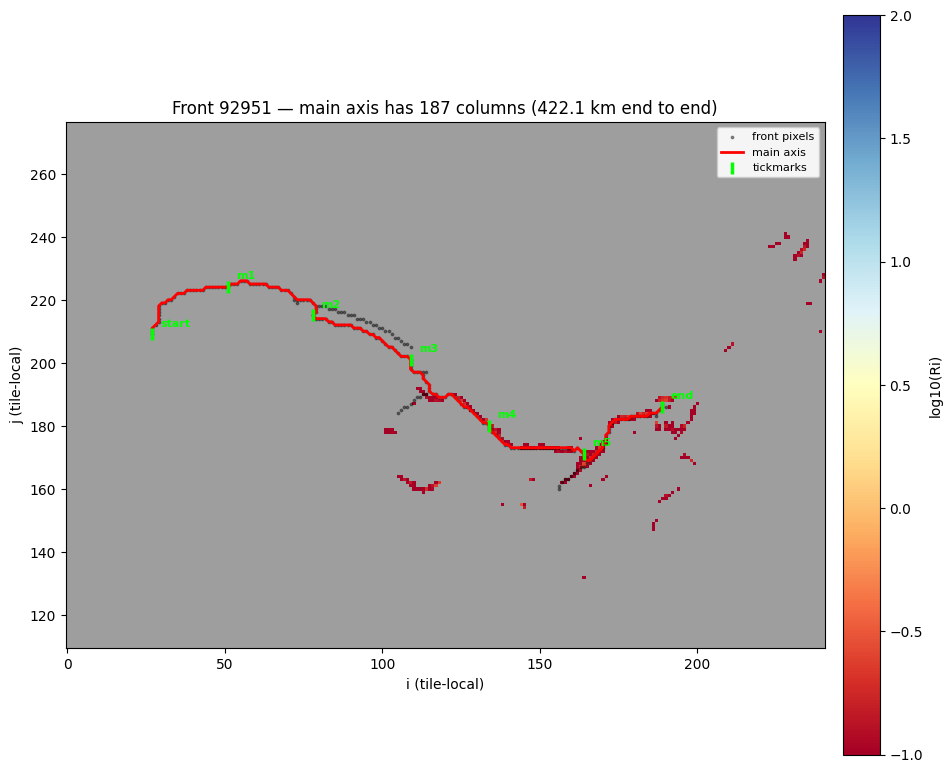


tickmarks along front 92951 — type one of these NAMES as CROSS_SECTION_AT below
  name  column       km       lon      lat
 start       0     0.00  -127.427   30.180
    m1      31    66.59  -126.927   30.428
    m2      62   136.10  -126.365   30.279
    m3      93   208.24  -125.719   30.047
    m4     124   281.81  -125.198   29.698
    m5     155   351.32  -124.573   29.548
   end     186   422.13  -124.052   29.798

rect locator for this front: --i 13069 --j 9561


In [11]:
# ===========================================================================
# >>> USER INPUT (2 of 3) — pick a front from the numbers on the map above <<<
# ===========================================================================

FRONT_LABEL = big[0]      # e.g. 12345; big[0] is the longest front in the tile
MARGIN      = 50          # px of context around the front's bbox
N_MARKS     = 7           # tickmarks along the axis (start + end + 5 between)

# ===========================================================================
# End of user input — the rest of the cell draws the inset with tickmarks.
# ===========================================================================
%matplotlib inline

from fronts.viz import curtains
from fronts.viz.fronts_3d import front_bbox_and_crop

j_sl, i_sl = front_bbox_and_crop(labels_tile, FRONT_LABEL, margin=MARGIN)
mask_crop  = (labels_tile == FRONT_LABEL)[j_sl, i_sl]

axis_path = curtains.extract_main_axis(mask_crop)              # (L, 2) in (j, i)
metrics   = curtains.path_metrics(axis_path, XC_rect[j_sl, i_sl], YC_rect[j_sl, i_sl])
L         = axis_path.shape[0]

# start, end, and N_MARKS-2 evenly spaced marks in between.  MARKS maps the
# name you will type in the next cell -> the main-axis column it stands for.
MARK_COLS  = np.unique(np.linspace(0, L - 1, N_MARKS).round().astype(int))
MARK_NAMES = ['start'] + [f'm{k}' for k in range(1, len(MARK_COLS) - 1)] + ['end']
MARKS      = dict(zip(MARK_NAMES, MARK_COLS.tolist()))

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(np.ma.masked_invalid(disp[j_sl, i_sl]), origin='lower', cmap=cmap,
               vmin=clim[0], vmax=clim[1], interpolation='nearest',
               extent=(i_sl.start - 0.5, i_sl.stop - 0.5,     # pixel centres on
                       j_sl.start - 0.5, j_sl.stop - 0.5))    # integer coords
fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02).set_label(style.title or fname)

jj, ii = np.where(mask_crop)
ax.scatter(ii + i_sl.start, jj + j_sl.start, s=3, c='k', alpha=0.4, label='front pixels')
ax.plot(axis_path[:, 1] + i_sl.start, axis_path[:, 0] + j_sl.start,
        color='red', lw=2.0, label='main axis')
ax.scatter(axis_path[MARK_COLS, 1] + i_sl.start, axis_path[MARK_COLS, 0] + j_sl.start,
           s=70, marker='|', c='lime', linewidths=2.5, zorder=5, label='tickmarks')
for c, name in zip(MARK_COLS, MARK_NAMES):
    ax.annotate(name, (axis_path[c, 1] + i_sl.start, axis_path[c, 0] + j_sl.start),
                textcoords='offset points', xytext=(6, 6), fontsize=8, color='lime',
                fontweight='bold')
ax.set_xlabel('i (tile-local)')
ax.set_ylabel('j (tile-local)')
ax.set_title(f"Front {FRONT_LABEL} — main axis has {L} columns "
             f"({metrics['dist_km'][-1]:.1f} km end to end)")
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

# The locator for fronts_viz_curtain: any pixel of this front, in rect indices.
I_LOC = int(axis_path[L // 2, 1]) + i_sl.start + rect_i0
J_LOC = int(axis_path[L // 2, 0]) + j_sl.start + rect_j0

print(f"\ntickmarks along front {FRONT_LABEL} — type one of these NAMES as "
      "CROSS_SECTION_AT below")
print(f"{'name':>6s} {'column':>7s} {'km':>8s} {'lon':>9s} {'lat':>8s}")
for name, c in MARKS.items():
    jc, ic = int(axis_path[c, 0]) + j_sl.start, int(axis_path[c, 1]) + i_sl.start
    print(f"{name:>6s} {c:>7d} {metrics['dist_km'][c]:>8.2f} "
          f"{XC_rect[jc, ic]:>9.3f} {YC_rect[jc, ic]:>8.3f}")
print(f"\nrect locator for this front: --i {I_LOC} --j {J_LOC}")

## Step (d) — USER INPUT: cross-section location, then all five figures

Set `CROSS_SECTION_AT` to one of the **tickmark names** printed above — `'start'`,
`'m1'`, `'m2'`, … , `'end'` — and the cross-front cut is taken there.  `'auto'` lets
the script choose instead (the column with the field extremum, restricted to clean
single-crossing transects).  A bare integer is also accepted if you want an exact
main-axis column that is not on a tickmark.

The cell then runs `fronts_viz_curtain` once and it writes **five PNGs**, which are
displayed below it:

1. `..._inset.png` — plan view: main axis, offset envelope, marked cross-section point
2. `..._isopycnal.png` — the field on the front's isopycnal, flattened (along-front / along-isopycnal)
3. `..._mainaxis.png` — along-front with depth
4. `..._offsets_n{N}.png` — along-front offsets, both sides
5. `..._perp.png` — the front cross-section at `PERP_POINT`

cross-section: tickmark 'm3' = main-axis column 93 (208.24 km along the front)
2026-08-20 12:01:18,868 | INFO | Loading density tile /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V5/SURF/20121109_120000/tiles/density_tile330_20121109T12.nc
2026-08-20 12:01:19,238 | INFO | Loading field tile /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V5/SURF/20121109_120000/tiles/ri_tile330_20121109T12.nc
2026-08-20 12:01:19,508 | INFO | Coloring curtains by Ri (Richardson number N2/S2, transform=log10)
2026-08-20 12:01:19,509 | INFO | Building tile lookup + remapping to rect-tile-local frame
2026-08-20 12:01:19,671 | INFO | Tile lat/lon bbox: lat [26.659, 38.267], lon [-127.990, -113.010]
2026-08-20 12:01:19,672 | INFO | Selected front label=92951 at tile-local (j=201, i=109) lon=-125.719 lat=30.047
2026-08-20 12:01:19,679 | INFO | Curtain depth extent: k=22 levels, z=[-0.5, -99.4] m
2026-08-20 12:01:19,688 | INFO | Main axis: 187 pixels
2026-08-20 12:01:19,699 | INFO | Isopycnal levels (kg m^-3): 23.92

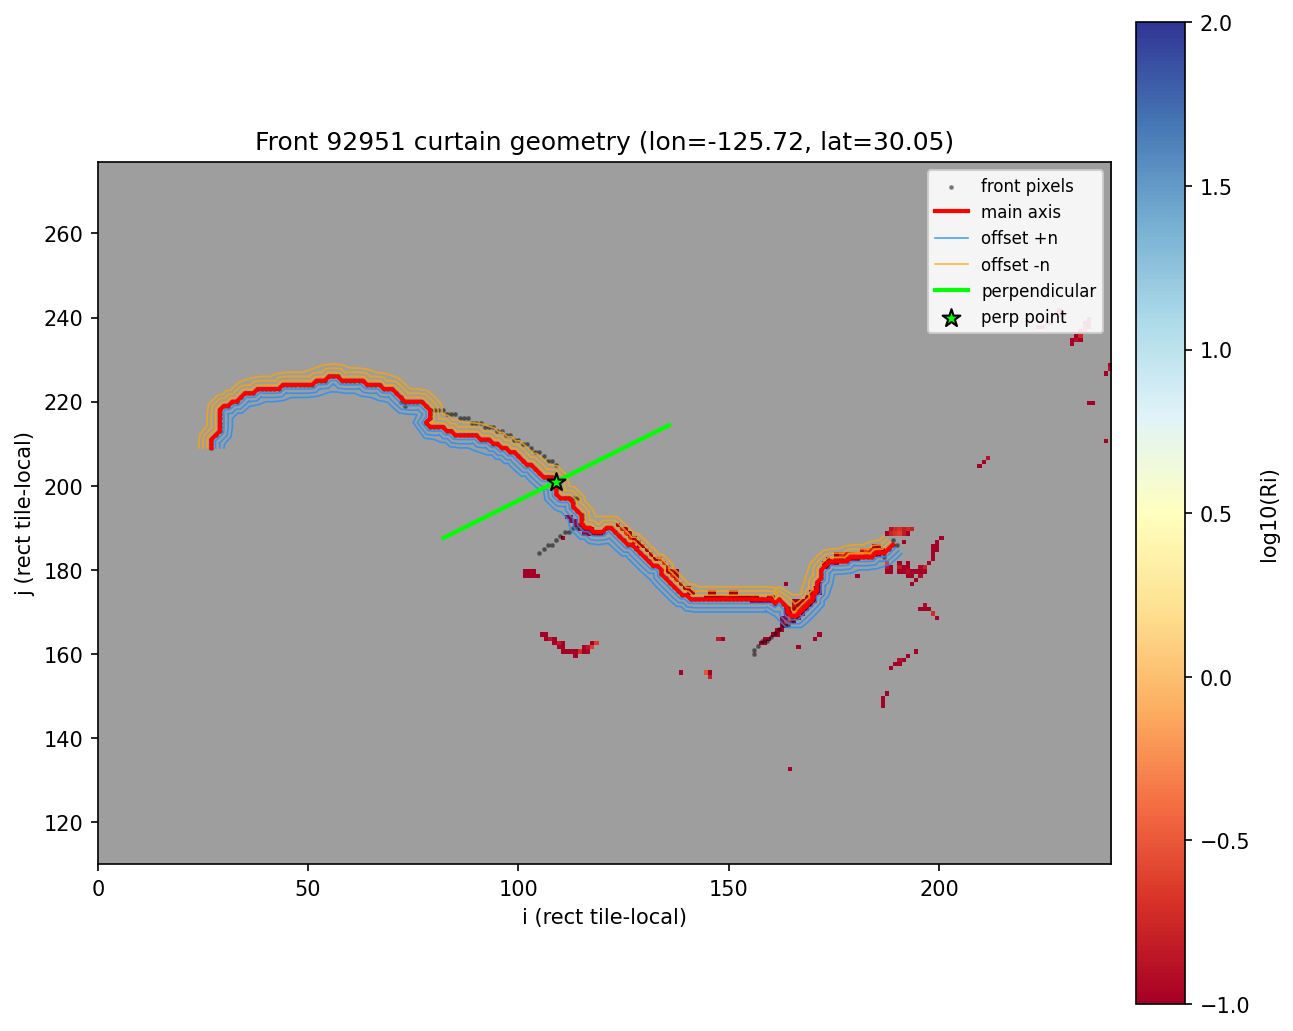


=== along-front / along-isopycnal: curtain_front92951_Ri_lat30.05_lon-125.72_isopycnal.png ===


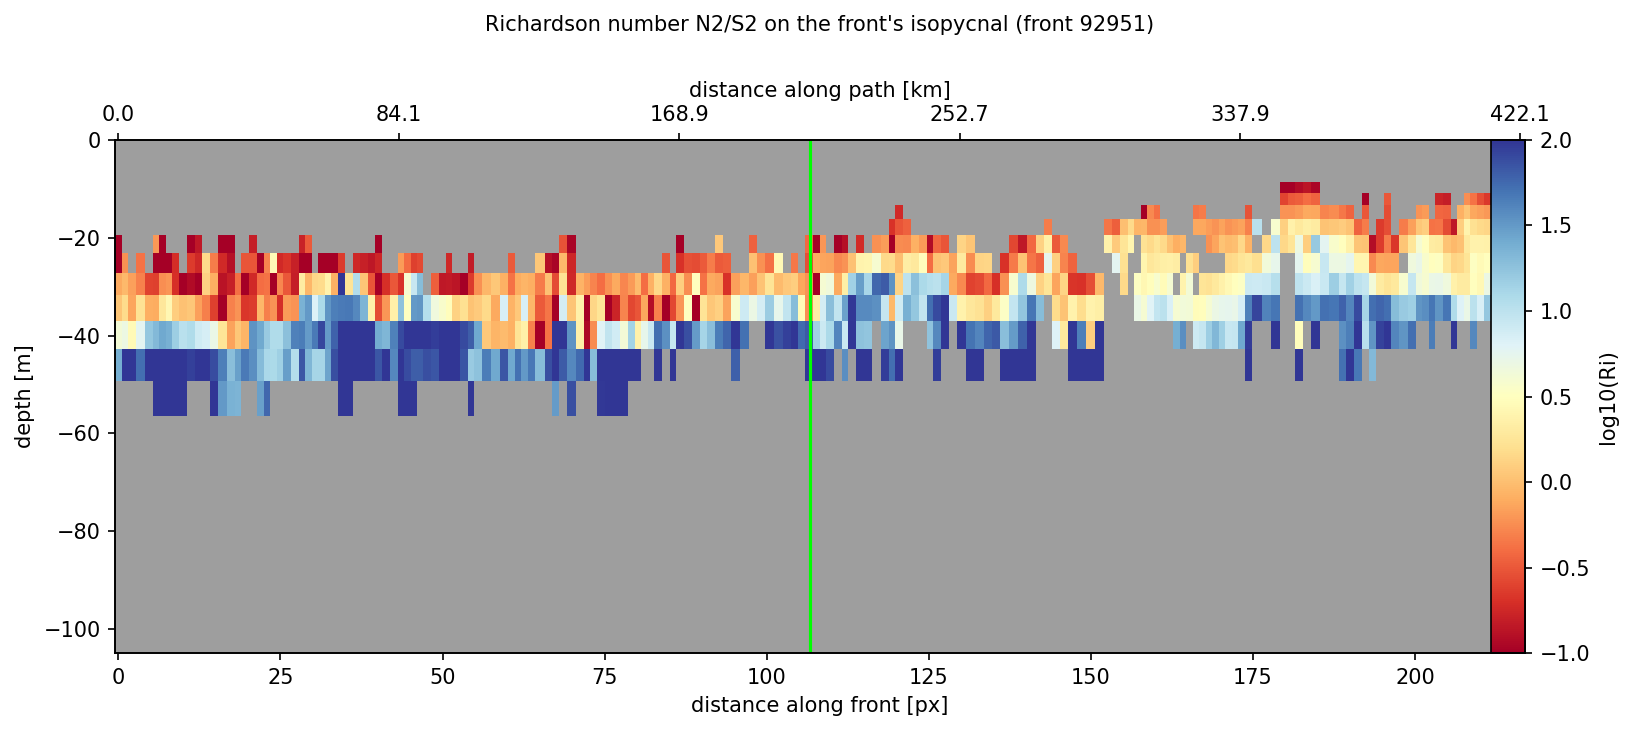


=== along-front with depth: curtain_front92951_Ri_lat30.05_lon-125.72_mainaxis.png ===


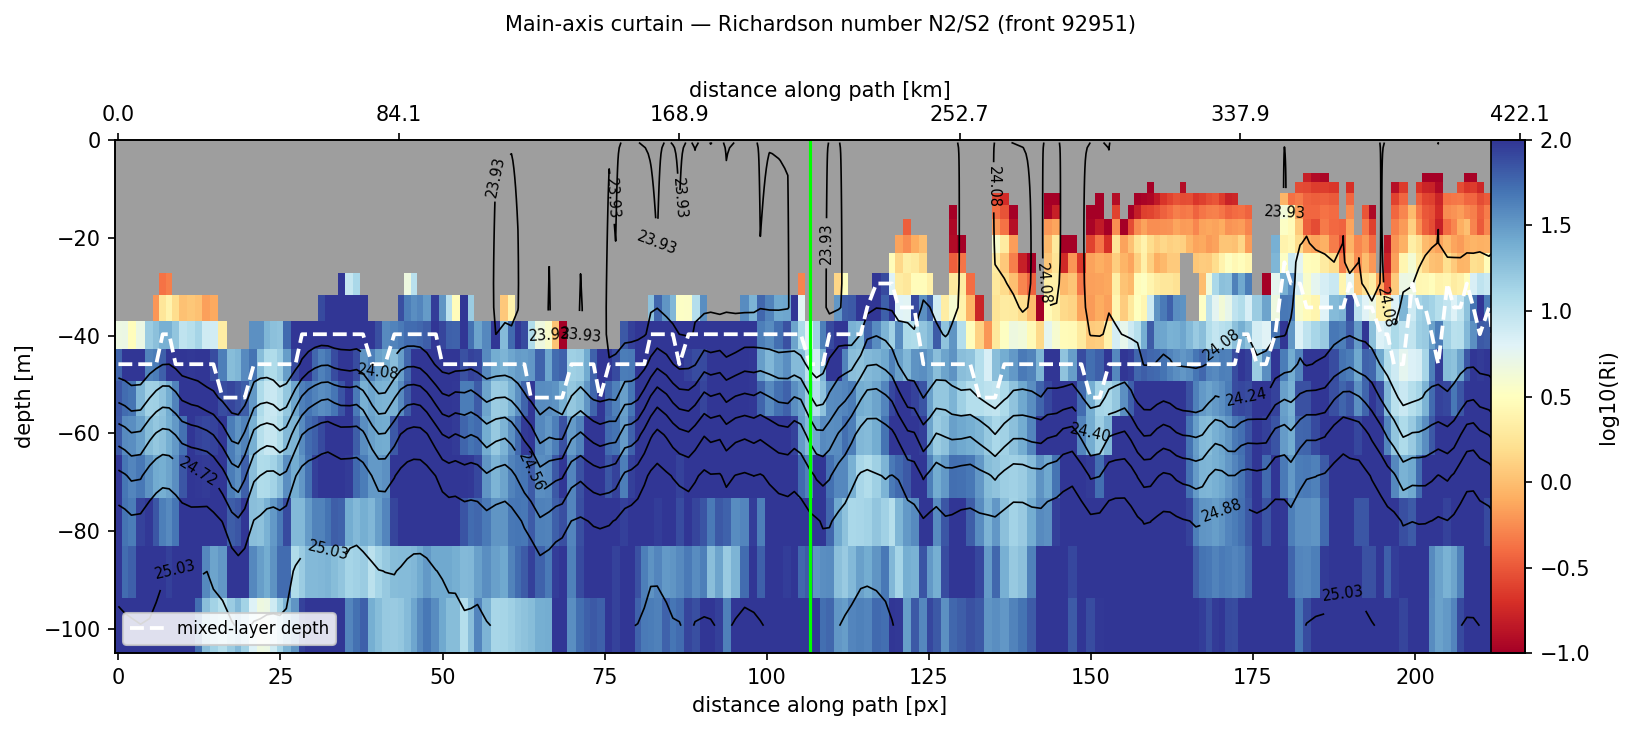


=== along-front offsets: curtain_front92951_Ri_lat30.05_lon-125.72_offsets_n3.png ===


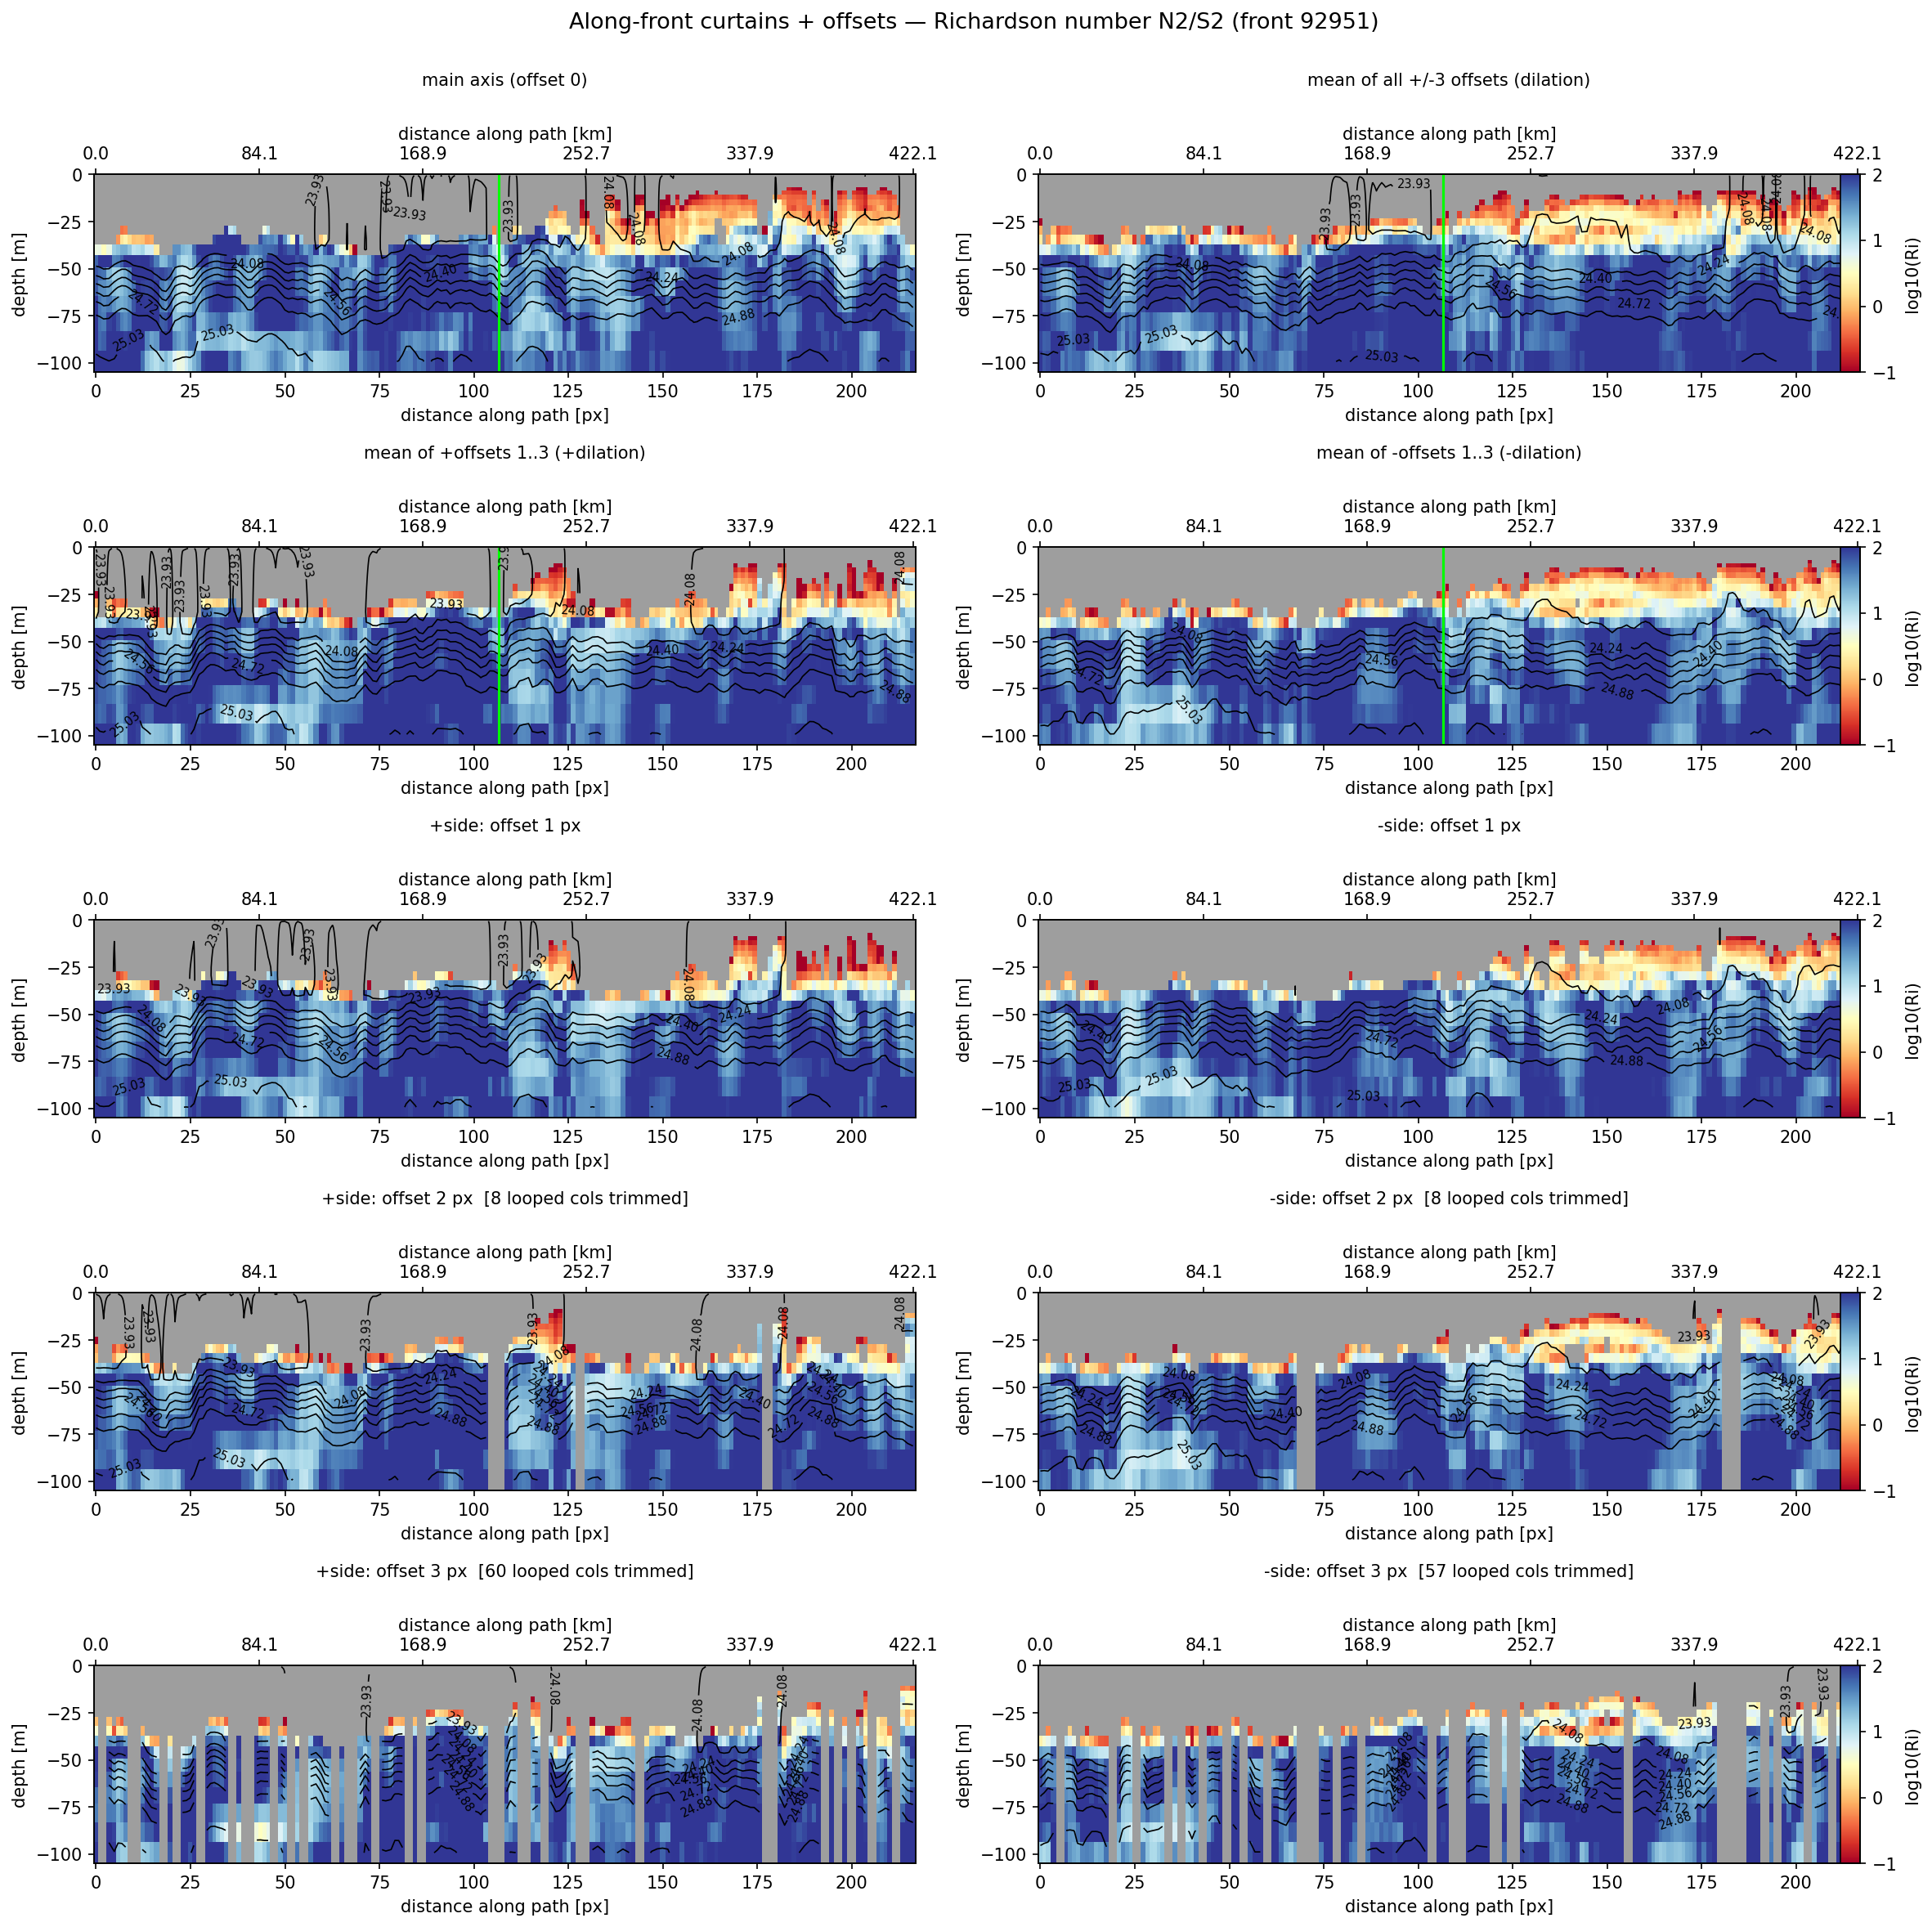


=== front cross-section: curtain_front92951_Ri_lat30.05_lon-125.72_perp.png ===


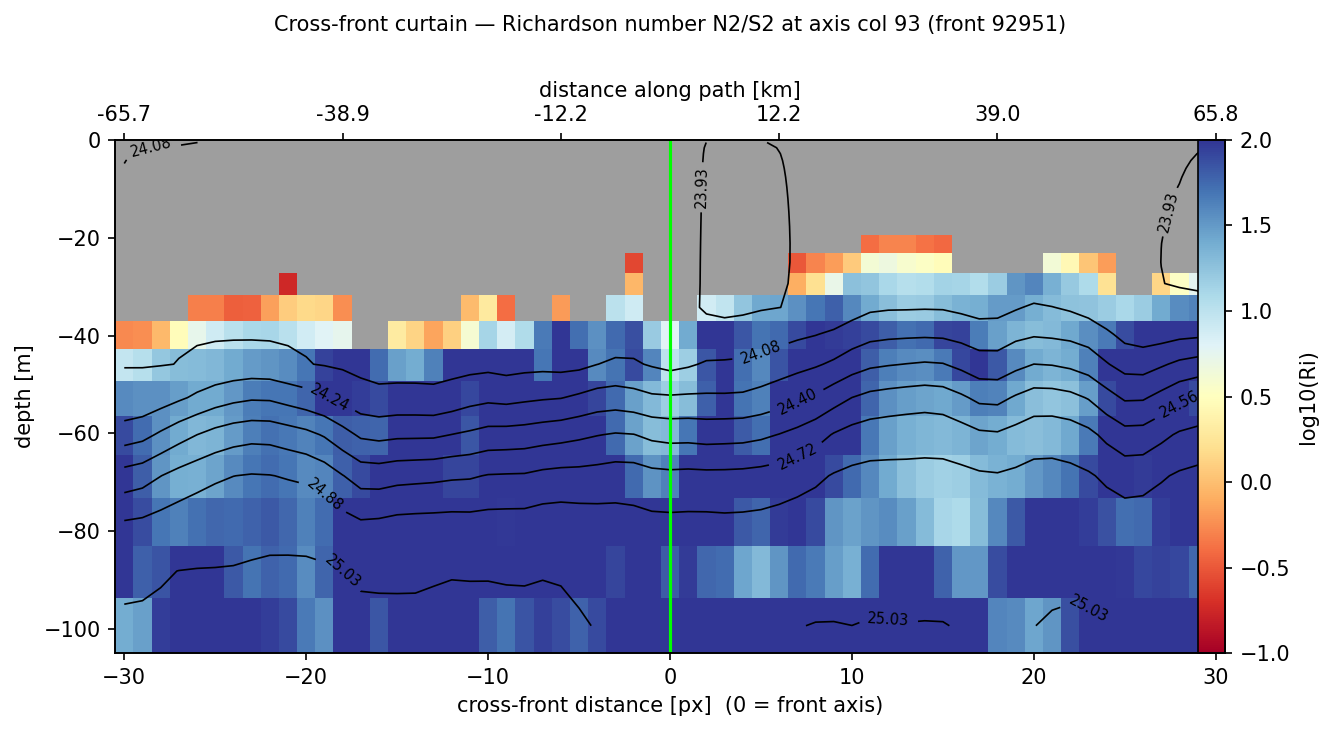

In [12]:
# ===========================================================================
# >>> USER INPUT (3 of 3) — WHERE along the front to cut the cross-section <<<
# ===========================================================================
#
# Type one of the tickmark NAMES printed by the cell above, e.g.
#
#       'start'   the first column of the main axis
#       'm1' ...  the evenly spaced marks along it
#       'end'     the last column
#
#       'auto'    let the script pick (the field extremum along the axis)
#       an int    an exact main-axis column, if you want one off the tickmarks
#
CROSS_SECTION_AT = 'm3'

# --- the rest of the curtain geometry (fine as-is) ------------------------
N_OFFSETS       = 3       # offset rows per side of the front
PERP_HALF_WIDTH = 30      # cross-section half-length in px (total 2N+1)
N_BELOW         = 3       # LLC levels kept below the deepest MLD

# ===========================================================================
# End of user input — the rest of the cell renders and displays the figures.
# ===========================================================================
from IPython.display import Image, display

from fronts.scripts import fronts_viz_curtain

if CROSS_SECTION_AT == 'auto':
    PERP_POINT = None
    print("cross-section: chosen by the script (field extremum)")
elif isinstance(CROSS_SECTION_AT, int):
    PERP_POINT = CROSS_SECTION_AT
    print(f"cross-section: main-axis column {PERP_POINT}")
elif CROSS_SECTION_AT in MARKS:
    PERP_POINT = MARKS[CROSS_SECTION_AT]
    print(f"cross-section: tickmark '{CROSS_SECTION_AT}' = main-axis column "
          f"{PERP_POINT} ({metrics['dist_km'][PERP_POINT]:.2f} km along the front)")
else:
    raise KeyError(f"{CROSS_SECTION_AT!r} is not a tickmark on this front. "
                   f"Pick one of {list(MARKS)}, or 'auto', or an int column.")

PREFIX = TILE_DIR / f"curtain_front{FRONT_LABEL}"

argv = ['--density-tile', str(DENSITY_TILE),
        '--field-tile', str(FIELD_TILE),
        '--labels', str(LABELS_FILE),
        '--i', str(I_LOC), '--j', str(J_LOC),
        '--margin', str(MARGIN),
        '--n-below', str(N_BELOW),
        '--n-offsets', str(N_OFFSETS),
        '--perp-half-width', str(PERP_HALF_WIDTH),
        '--isopycnal-curtain',
        '--output-prefix', str(PREFIX)]
if PERP_POINT is not None:
    argv += ['--perp-point', str(PERP_POINT)]

fronts_viz_curtain.main(argv)

# The script bakes the field name and the front's lat/lon into each filename,
# so just collect whatever it wrote under this prefix.
for name, tag in [('2-D inset (plan view)',            '_inset.png'),
                  ('along-front / along-isopycnal',    '_isopycnal.png'),
                  ('along-front with depth',           '_mainaxis.png'),
                  ('along-front offsets',              f'_offsets_n{N_OFFSETS}.png'),
                  ('front cross-section',              '_perp.png')]:
    hits = sorted(TILE_DIR.glob(f"{PREFIX.name}_*{tag}"))
    if not hits:
        print(f"! no figure found for {name} ({tag})")
        continue
    print(f"\n=== {name}: {hits[-1].name} ===")
    display(Image(filename=str(hits[-1])))